In [9]:
%python.exe -m pip install --upgrade pip

UsageError: Line magic function `%python.exe` not found.


In [2]:
%pip -q install sentence-transformers pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\romancollinge\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [3]:
from sentence_transformers import SentenceTransformer, util
import torch
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Tuple

In [4]:
def clean_list(words: List[str], lowercase: bool = True, dedup: bool = True) -> List[str]:
    if lowercase:
        words = [w.lower() if isinstance(w, str) else w for w in words]
    if dedup:
        seen = set()
        words = [w for w in words if isinstance(w, str) and not (w in seen or seen.add(w))]
    words = [w.strip() for w in words if isinstance(w, str) and w.strip()]
    if not words:
        raise ValueError("Your list ended up empty after cleaning. Please add at least one word.")
    return words

def load_model(model_name: str) -> SentenceTransformer:
    device = "cuda" if torch.cuda.is_available() else "cpu"
    return SentenceTransformer(model_name, device=device)

def encode_lists(model: SentenceTransformer, list_A: List[str], list_B: List[str]):
    emb_A = model.encode(list_A, convert_to_tensor=True, normalize_embeddings=True)
    emb_B = model.encode(list_B, convert_to_tensor=True, normalize_embeddings=True)
    return emb_A, emb_B

def similarity_table(emb_A, emb_B, list_A: List[str], list_B: List[str]) -> pd.DataFrame:
    sims = util.cos_sim(emb_A, emb_B).cpu().numpy()
    return pd.DataFrame(sims, index=list_A, columns=list_B)

def plot_heatmap(df: pd.DataFrame, title: str = "Word Similarity Heatmap (A vs B)") -> None:
    plt.figure(figsize=(max(6, 0.8*len(df.columns)), max(4, 0.6*len(df.index))))
    plt.imshow(df.values, cmap="viridis", aspect="auto", vmin=0, vmax=1)
    plt.colorbar(label="cosine similarity")
    plt.xticks(range(len(df.columns)), df.columns, rotation=45, ha="right")
    plt.yticks(range(len(df.index)), df.index)
    plt.title(title)
    if len(df.index) <= 10 and len(df.columns) <= 10:
        for i in range(len(df.index)):
            for j in range(len(df.columns)):
                plt.text(j, i, f"{df.values[i, j]:.2f}", ha="center", va="center")
    plt.tight_layout()
    plt.show()

def top_matches_per_A(df: pd.DataFrame, k: int = 3) -> pd.DataFrame:
    k = min(k, df.shape[1])
    rows = []
    for a in df.index:
        row = df.loc[a].sort_values(ascending=False)
        tops = ", ".join([f"{b} ({row[b]:.3f})" for b in row.index[:k]])
        rows.append((a, tops))
    return pd.DataFrame(rows, columns=["Word in A", "Top matches in B (similarity)"])

In [5]:
def run_pipeline(list_A: List[str], list_B: List[str], model_name: str = "bert-base-nli-mean-tokens",
                 lowercase: bool = True, dedup: bool = True
                 ) -> Tuple[pd.DataFrame, pd.DataFrame, str]:
    # Clean
    list_A = clean_list(list_A, lowercase, dedup)
    list_B = clean_list(list_B, lowercase, dedup)

    # Model
    model = load_model(model_name)

    # Encode
    emb_A, emb_B = encode_lists(model, list_A, list_B)

    # Similarity table
    df = similarity_table(emb_A, emb_B, list_A, list_B)
    return df

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

C:\Users\romancollinge\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\romancollinge\.cache\huggingface\hub\models--sentence-transformers--bert-base-nli-mean-tokens. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

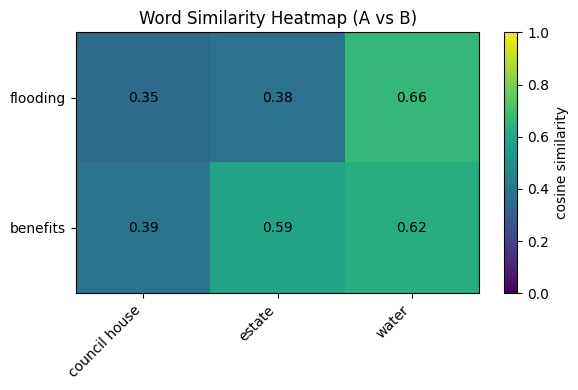

In [6]:
# Inputs
list_A = ["flooding", "benefits"]
list_B = ["council house", "estate", "water"]

# Model choice
MODEL_NAME = "bert-base-nli-mean-tokens"  # try: "all-MiniLM-L6-v2" or "all-mpnet-base-v2"

# Run
df = run_pipeline(list_A, list_B, model_name=MODEL_NAME)

plot_heatmap(df)
